In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold

from xgboost import XGBClassifier
from tqdm.auto import trange


In [39]:
# Загрузка данных
features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap75.csv')

# Разбиение данных на признаки и целевую переменную
X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

num_of_features = len(X.columns)
print(f"Количество признаков: {num_of_features}")


1056


In [6]:
n_iter = 100
feature_importances = np.zeros(num_of_features)

for i in trange(n_iter, desc='Progress', colour='green'):

    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=i)
    
    # Обучение XGBoost для получения важности признаков
    model = XGBClassifier(random_state=i, device="cuda", tree_method="hist", n_jobs=-1)
    model.fit(X_train, y_train)
    
    feature_importances += model.feature_importances_
    
# Нормализация и сортировка
mean_importance = feature_importances / n_iter
importance_df = pd.DataFrame({
    'Importance': mean_importance
    }, index=X.columns
    ).sort_values('Importance', ascending=False)

importance_df.to_csv(f"DATA/related_info/feature_importances_xgb_mean_of_{n_iter}iter.csv")
print(importance_df)


Progress:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
n_iter = 100

# Загрузка данных
importance_df = pd.read_csv(f"DATA/related_info/feature_importances_xgb_mean_of_{n_iter}.csv", index_col=0)

# Расчет корреляции
correlation_matrix = X.corr(method='spearman')

# Пороги корреляции
thresholds = [0.8, 0.85, 0.9, 0.95, 0.98, 1]

# Загрузка порядка признаков из JSON файла
with open("DATA/related_info/sorted_feature_extraction_time.json", 'r') as f:
    sorted_features = list(json.load(f).keys()) + ["Класс"]
    
for threshold in thresholds:
    # Фильтрация пар с высокой корреляцией (исключая диагональ)
    high_corr = (correlation_matrix.abs() > threshold) & (correlation_matrix != 1.0)
    
    # Преобразование матрицы в таблицу пар
    high_corr_pairs = correlation_matrix[high_corr].stack().reset_index()
    high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
    
    # Удаление дубликатов пар (A-B и B-A → останется только A-B)
    high_corr_pairs = high_corr_pairs[high_corr_pairs['Feature_1'] < high_corr_pairs['Feature_2']]
    
    # Удаление коррелированных признаков (оставляем более важные)
    to_drop = set()
    for _, row in high_corr_pairs.iterrows():
        f1, f2 = row['Feature_1'], row['Feature_2']
        if f1 in importance_df.index and f2 in importance_df.index:
            if importance_df.loc[f1, 'Importance'] > importance_df.loc[f2, 'Importance']:
                to_drop.add(f2)
            else:
                to_drop.add(f1)
    
    df_reduced = features_df.drop(columns=to_drop)
    
    print(f"Порог: {threshold}")
    print(f"Удалено признаков: {len(to_drop)}")
    print(f"Оставлено признаков: {df_reduced.shape[1] - 1}\n")
      
    # Переставляем столбцы
    df_reordered = df_reduced[sorted_features]
    
    # Сохраняем результат
    df_reordered.to_csv(f"reduced_features_corr_threshold_{threshold}_reordered.csv", index=False)
    

In [ ]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        
        if isinstance(obj, (np.int32, np.int64)):
            return int(obj)
            
        elif isinstance(obj, (np.float32, np.float64)):
            return float(obj)
            
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
            
        return super().default(obj)
        

thresholds = [0.8, 0.85, 0.9, 0.95, 0.98, 1]

# Создаем папку для результатов, если её нет
os.makedirs('DATA/rfecv_results', exist_ok=True)

for threshold in thresholds:
    # Загрузка данных
    df = pd.read_csv(f"DATA/reduced_features/reduced_features_corr_threshold_{threshold}_reordered.csv")
    X = df.drop(columns=["Класс"])
    y = df["Класс"].values

    # Настройка RFECV
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    
    rfecv = RFECV(
        cv=cv, 
        step=1, 
        n_jobs=1,
        verbose=1,
        scoring='accuracy', 
        estimator=XGBClassifier(random_state=42, 
                                device="cuda", 
                                tree_method="hist", 
                                predictor="gpu_predictor")
    ) 
    
    # Выполнение RFECV
    rfecv.fit(X, y)

    # Сбор полной информации
    result = {
        'threshold': threshold,                                            # Порог корреляции
        'optimal_num_features': rfecv.n_features_,                         # Оптимальное число признаков, найденное RFECV
        'optimal_features': X.columns[rfecv.support_].tolist(),            # Список имен лучших признаков (где rfecv.support_ = True)
        'ranking': rfecv.ranking_.tolist(),                                # Порядок исключения признаков (1 - лучшие)
        'mean_test_score': rfecv.cv_results_['mean_test_score'].tolist(),  # Средняя точность
        'n_features': rfecv.cv_results_['n_features'].tolist()             # Число признаков на каждом шаге
    }

    # Сохранение JSON для текущего threshold
    json_filename = f"DATA/rfecv_results/rfecv_threshold_{threshold}.json"
    with open(json_filename, 'w', encoding='utf-8') as f:
        json.dump(result, f, cls=NumpyEncoder, ensure_ascii=False, indent=2)
    
    print(f"Результаты для порога корреляции {threshold} сохранены в JSON файл: {json_filename}")
    print(f"Лучшее число признаков для порога корреляции {threshold}: {rfecv.n_features_}")
    print(f"Лучшая accuracy: {max(rfecv.cv_results_['mean_test_score']):.4f}\n")

2026-02-23 23:21:00.482072: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 23:21:00.485611: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 23:21:00.535989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 23:21:01.351851: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Fitting estimator with 1056 features.
Fitting estimator with 1055 features.
Fitting estimator with 1054 features.
Fitting estimator with 1053 features.
Fitting estimator with 1052 features.
Fitting estimator with 1051 features.
Fitting estimator with 1050 features.
Fitting estimator with 1049 features.
Fitting estimator with 1048 features.
Fitting estimator with 1047 features.
Fitting estimator with 1046 features.
Fitting estimator with 1045 features.
Fitting estimator with 1044 features.
Fitting estimator with 1043 features.
Fitting estimator with 1042 features.
Fitting estimator with 1041 features.
Fitting estimator with 1040 features.
Fitting estimator with 1039 features.
Fitting estimator with 1038 features.
Fitting estimator with 1037 features.
Fitting estimator with 1036 features.
Fitting estimator with 1035 features.
Fitting estimator with 1034 features.
Fitting estimator with 1033 features.


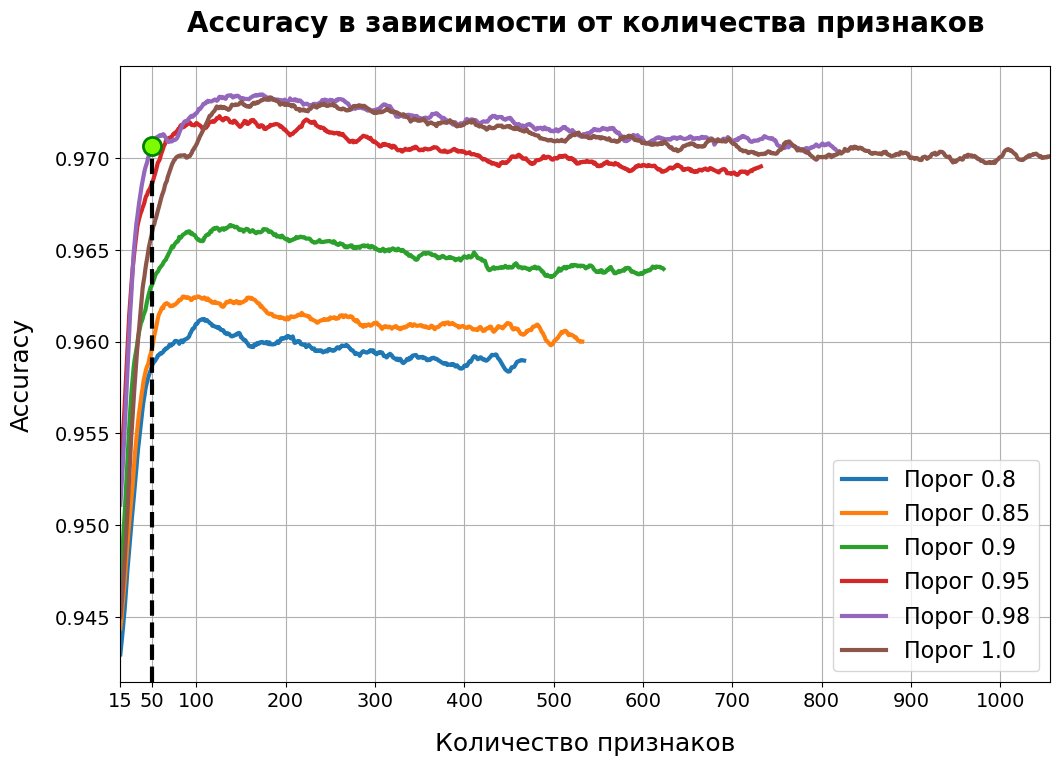

In [26]:
thresholds = [0.8, 0.85, 0.9, 0.95, 0.98, 1]

def moving_average(data, median_window_size):
    
    if median_window_size % 2 == 0:
        raise ValueError("Размер окна должен быть нечетным")
    
    data = np.array(data)
    half_window = median_window_size // 2
    
    # Дополнение массива
    padded_data = np.pad(data, (half_window, half_window), mode='edge')

    # Ядро для свертки
    kernel = np.ones(median_window_size) / median_window_size
    
    # Применение свертки
    result = np.convolve(padded_data, kernel, mode='valid')
    
    return result

# Параметры
a = 15    # a э [1; inf]
b = 1056  # b э [a+1; inf]
median_window_size = 15  # Размер окна для сглаживания

json_file_names = [name for name in os.listdir('DATA/rfecv_results') if "json" in name]
rfecv_results_list = []

for name in json_file_names: 
    with open(f'DATA/rfecv_results/{name}', 'r', encoding='utf-8') as file:
        rfecv_results_list.append(json.load(file))
        
a = max(1, a)
all_x_ranges = []

plt.figure(figsize=(12, 8))

for res, threshold in zip(rfecv_results_list, thresholds):
    new_a = min(len(res['mean_test_score']), a)
    new_b = min(len(res['mean_test_score']), b)
    
    smoothed_res = moving_average(res['mean_test_score'][new_a-1:new_b], median_window_size)
    x_range = range(new_a, new_b+1)
    all_x_ranges.append(x_range)
    
    plt.plot(x_range, 
             smoothed_res,
             label=f'Порог {float(threshold)}', linewidth=3)

    if threshold == 0.98:
        h = smoothed_res

min_x = min(r.start for r in all_x_ranges)
max_x = max(r.stop - 1 for r in all_x_ranges)
    
plt.xlim(min_x, max_x)

# Или раздельно для осей X и Y
plt.tick_params(axis='x', labelsize=14)  # только ось X
plt.tick_params(axis='y', labelsize=14)  # только ось Y

plt.xticks([a] + [50] + [i for i in range(0, b + 1, 100) if i > a])
plt.grid()

# --- ДОБАВЛЕННЫЙ КОД: пунктирная линия и красная точка ---
# Находим максимальное значение accuracy для порога 1.0
max_accuracy_index = 50
max_accuracy_value = h[max_accuracy_index]
max_accuracy_x = 50

# Рисуем пунктирную линию от оси абсцисс до точки максимума
plt.axvline(x=max_accuracy_x+1, ymin=0, ymax=(max_accuracy_value - plt.ylim()[0]) / (plt.ylim()[1] - plt.ylim()[0])-0.01, 
            color='black', linestyle='--', linewidth=3, alpha=1)

# Рисуем жирную красную точку в месте касания
plt.scatter(max_accuracy_x, max_accuracy_value-0.0005, color='lawngreen', s=170, zorder=5, linewidth=2, edgecolor='g')

plt.xlabel("Количество признаков",
           fontsize=18, 
           fontweight='medium',
           labelpad=15)

plt.ylabel("Accuracy",
           fontsize=18, 
           fontweight='medium',
           labelpad=15)

plt.title(f"Accuracy в зависимости от количества признаков", 
          fontweight='demibold', 
          fontsize=20,
          pad=25)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='lower right', fontsize=14)

plt.legend(loc='lower right', fontsize=16)

plt.savefig('123.png', dpi=600, bbox_inches='tight')

plt.show()

In [24]:
len(smoothed_res)

1042

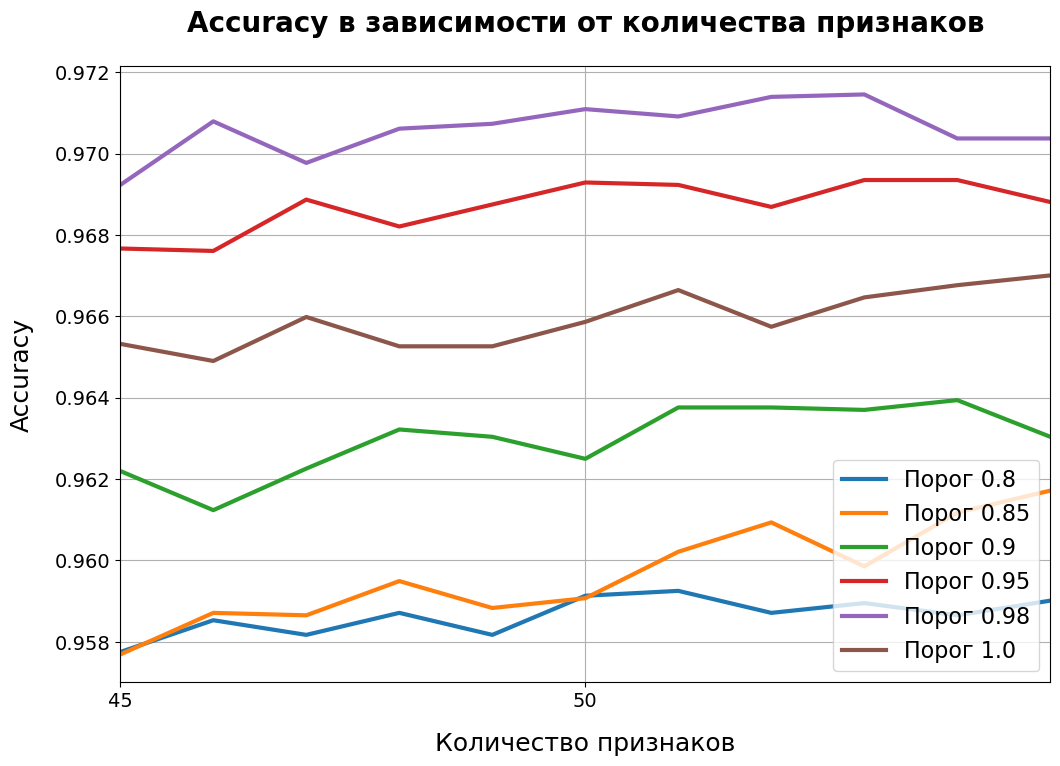

In [31]:
thresholds = [0.8, 0.85, 0.9, 0.95, 0.98, 1]

def moving_average(data, median_window_size):
    
    if median_window_size % 2 == 0:
        raise ValueError("Размер окна должен быть нечетным")
    
    data = np.array(data)
    half_window = median_window_size // 2
    
    # Дополнение массива
    padded_data = np.pad(data, (half_window, half_window), mode='edge')

    # Ядро для свертки
    kernel = np.ones(median_window_size) / median_window_size
    
    # Применение свертки
    result = np.convolve(padded_data, kernel, mode='valid')
    
    return result

# Параметры
a = 45    # a э [1; inf]
b = 55  # b э [a+1; inf]
median_window_size = 1  # Размер окна для сглаживания

json_file_names = [name for name in os.listdir('DATA/rfecv_results') if "json" in name]
rfecv_results_list = []

for name in json_file_names: 
    with open(f'DATA/rfecv_results/{name}', 'r', encoding='utf-8') as file:
        rfecv_results_list.append(json.load(file))
        
a = max(1, a)
all_x_ranges = []

plt.figure(figsize=(12, 8))

for res, threshold in zip(rfecv_results_list, thresholds):
    new_a = min(len(res['mean_test_score']), a)
    new_b = min(len(res['mean_test_score']), b)
    
    smoothed_res = moving_average(res['mean_test_score'][new_a-1:new_b], median_window_size)
    x_range = range(new_a, new_b+1)
    all_x_ranges.append(x_range)
    
    plt.plot(x_range, 
             res['mean_test_score'][new_a-1:new_b],
             label=f'Порог {float(threshold)}', linewidth=3)

    if threshold == 0.98:
        h = smoothed_res

min_x = min(r.start for r in all_x_ranges)
max_x = max(r.stop - 1 for r in all_x_ranges)
    
plt.xlim(min_x, max_x)

# Или раздельно для осей X и Y
plt.tick_params(axis='x', labelsize=14)  # только ось X
plt.tick_params(axis='y', labelsize=14)  # только ось Y

plt.xticks([a] + [50] + [i for i in range(0, b + 1, 100) if i > a])
plt.grid()

# --- ДОБАВЛЕННЫЙ КОД: пунктирная линия и красная точка ---
# Находим максимальное значение accuracy для порога 1.0
max_accuracy_index = 5
max_accuracy_value = h[max_accuracy_index]
max_accuracy_x = 5

# Рисуем пунктирную линию от оси абсцисс до точки максимума
plt.axvline(x=max_accuracy_x, ymin=0, ymax=(max_accuracy_value - plt.ylim()[0]) / (plt.ylim()[1] - plt.ylim()[0])-0.01, 
            color='red', linestyle='--', linewidth=2, alpha=0.7)

# Рисуем жирную красную точку в месте касания
plt.scatter(max_accuracy_x, max_accuracy_value-0.0005, color='red', s=100, zorder=5, linewidth=2.5, edgecolor='darkred')

plt.xlabel("Количество признаков",
           fontsize=18, 
           fontweight='medium',
           labelpad=15)

plt.ylabel("Accuracy",
           fontsize=18, 
           fontweight='medium',
           labelpad=15)

plt.title(f"Accuracy в зависимости от количества признаков", 
          fontweight='demibold', 
          fontsize=20,
          pad=25)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='lower right', fontsize=14)

plt.legend(loc='lower right', fontsize=16)

plt.savefig('123.png', dpi=600, bbox_inches='tight')

plt.show()